# Proyek Analisis Data: Brazilian E-Commerce Public Dataset by Olist
- **Nama:** I Putu Agus Wahyu Wirakusuma Putra
- **Email:** putuaguswahyuwp@gmail.com
- **ID Dicoding:** gus_wahyu

## Menentukan Pertanyaan Bisnis

- Bagaimana korelasi antara durasi pengiriman dengan skor ulasan pelanggan pada periode 2017–2018, dan tahap logistik mana yang paling memengaruhi keterlambatan?
- Kategori produk apa yang memberikan kontribusi pendapatan (Monetary) terbesar di 5 negara bagian (State) dengan jumlah transaksi tertinggi di Brasil?
- Bagaimana klasifikasi pelanggan berdasarkan skor RFM (Recency, Frequency, Monetary), dan segmen mana yang memiliki nilai ekonomi paling strategis bagi perusahaan?

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

## Data Wrangling

Proses ini bertujuan untuk mengumpulkan semua data yang diperlukan dari berbagai sumber guna menjawab pertanyaan bisnis yang telah ditetapkan. Pada tahap ini, data mentah berupa kumpulan berkas CSV dimuat ke dalam dataframe agar siap untuk diproses pada tahap berikutnya.

### Gathering Data

Pada tahap ini, kita memuat lima dataset utama dari Olist E-Commerce yang relevan dengan pertanyaan bisnis.

In [2]:
# Memuat data customers
customers_df = pd.read_csv("data/olist_customers_dataset.csv")
print("Menampilkan 5 data teratas dari customers_df:")
customers_df.head()

Menampilkan 5 data teratas dari customers_df:


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


**Insight:**
- Dataset customers_df terdiri dari 5 kolom utama yaitu customer_id, customer_unique_id, customer_zip_code_prefix, customer_city, dan customer_state.
- Terdapat perbedaan antara customer_id (ID untuk setiap pesanan spesifik) dan customer_unique_id (ID unik untuk satu pelanggan). Hal ini sangat penting untuk Analisis RFM, karena customer_unique_id dapat digunakan untuk menghitung frekuensi belanja pelanggan yang sama.
- Data mencakup informasi geografis yang mendetail (kota dan negara bagian), yang akan digunakan untuk menjawab pertanyaan tentang distribusi penjualan berdasarkan wilayah di Brasil.
- Data menunjukkan keberagaman lokasi pelanggan, seperti kota Franca di negara bagian SP (São Paulo), yang memberikan indikasi awal mengenai persebaran basis pelanggan.

In [3]:
# Memuat data orders
orders_df = pd.read_csv("data/olist_orders_dataset.csv")
print("\nMenampilkan 5 data teratas dari orders_df:")
orders_df.head()


Menampilkan 5 data teratas dari orders_df:


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


**Insight:**
- Dataset orders_df mengandung informasi krusial mengenai alur transaksi, mulai dari order_id, customer_id, hingga status pesanan (order_status).
- Terdapat lima kolom timestamp yang mencatat setiap tahap logistik, mulai dari waktu pembelian (order_purchase_timestamp) hingga waktu sampai di pelanggan (order_delivered_customer_date).
- Data ini menjadi dasar utama untuk menjawab pertanyaan bisnis pertama mengenai waktu pemrosesan pesanan dan identifikasi keterlambatan pengiriman.
- Kolom order_status pada sampel data menunjukkan status 'delivered', yang mengonfirmasi bahwa data ini siap digunakan untuk menganalisis pesanan yang telah selesai.

In [4]:
# Memuat data order_items
order_items_df = pd.read_csv("data/olist_order_items_dataset.csv")
print("\nMenampilkan 5 data teratas dari order_items_df:")
order_items_df.head()


Menampilkan 5 data teratas dari order_items_df:


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


**Insight:**
- Dataset ini memuat rincian transaksi per item, termasuk price (harga barang) dan freight_value (ongkos kirim).
- Kolom price akan menjadi komponen utama dalam perhitungan variabel Monetary pada Analisis RFM.
- Data menyertakan shipping_limit_date yang dapat digunakan untuk menganalisis performa kecepatan penjual dalam memproses pesanan.

In [5]:
# Memuat data order_reviews
order_reviews_df = pd.read_csv("data/olist_order_reviews_dataset.csv")
print("\nMenampilkan 5 data teratas dari order_reviews_df:")
order_reviews_df.head()


Menampilkan 5 data teratas dari order_reviews_df:


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


**Insight:**
- Dataset menyediakan variabel review_score dengan skala 1–5 yang merepresentasikan tingkat kepuasan pelanggan.
- Terdapat banyak nilai NaN pada kolom review_comment_title dan review_comment_message, sehingga diperlukan penanganan missing values pada tahap Cleaning Data agar analisis tetap berjalan lancar.
- Data ulasan ini akan dihubungkan dengan waktu pengiriman dari orders_df untuk menjawab pertanyaan bisnis pertama.

In [6]:
# Memuat data products
products_df = pd.read_csv("data/olist_products_dataset.csv")
print("\nMenampilkan 5 data teratas dari products_df:")
products_df.head()


Menampilkan 5 data teratas dari products_df:


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


**Insight:**
- Dataset mengandung informasi kategori produk melalui kolom product_category_name.
- Informasi kategori ini sangat krusial untuk menjawab pertanyaan bisnis kedua mengenai distribusi penjualan kategori produk di berbagai wilayah Brasil.
- Tersedia juga data atribut fisik produk (berat dan dimensi) yang dapat menjadi faktor tambahan dalam menganalisis pengaruh logistik terhadap kepuasan pelanggan.

### Assessing Data

Tahapan ini bertujuan untuk menilai kualitas dan struktur data secara menyeluruh untuk mengidentifikasi berbagai masalah seperti nilai yang hilang (missing values), data yang tidak konsisten, keberadaan data duplikat, hingga kesalahan tipe data. Penilaian dilakukan pada setiap dataframe tunggal untuk memahami karakteristik awal sebelum pengolahan lebih lanjut.

Assessing customers_df

In [7]:
customers_df.info()
print("Jumlah duplikasi: ", customers_df.duplicated().sum())
customers_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
Jumlah duplikasi:  0


,customer_zip_code_prefix
count,99441.000000
mean,35137.474583
std,29797.938996
min,1003.000000
25%,11347.000000
50%,24416.000000
75%,58900.000000
max,99990.000000


**Insight Assessing customers_df:**
- Tidak terdapat missing values pada kelima kolom dan tidak ditemukan data duplikat.
- Tipe Data: Kolom customer_zip_code_prefix bertipe integer, sedangkan kolom lainnya bertipe object.
- Terdapat 99.441 entri pelanggan unik yang siap digunakan untuk analisis berbasis lokasi (kota/negara bagian).

Assessing orders_df

In [8]:
orders_df.info()
print("Jumlah duplikasi: ", orders_df.duplicated().sum())
orders_df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB
Jumlah duplikasi:  0


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


**Insight Assessing orders_df:**
- Tidak ada duplikasi, namun terdapat missing values pada kolom order_approved_at (160), order_delivered_carrier_date (1.783), dan order_delivered_customer_date (2.965).
- Seluruh kolom timestamp masih bertipe object. Ini harus diubah ke tipe datetime agar durasi pengiriman dapat dihitung.
- Terdapat 8 status pesanan unik dengan status 'delivered' sebagai yang paling dominan (96.478 entri).

Assessing order_items_df

In [9]:
order_items_df.info()
print("Jumlah duplikasi: ", order_items_df.duplicated().sum())
order_items_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB
Jumlah duplikasi:  0


,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


**Insight Assessing order_items_df:**
- Dataset bersih dari missing values dan data duplikat (112.650 entri).
- Harga barang (price) memiliki variansi yang sangat tinggi (std: 183.6), dengan harga maksimum mencapai 6.735, yang mengindikasikan adanya produk premium atau outlier.
- Nilai rata-rata biaya pengiriman adalah 19.99, yang akan digunakan dalam perhitungan total pendapatan.

Assessing order_reviews_df

In [10]:
order_reviews_df.info()
print("Jumlah duplikasi: ", order_reviews_df.duplicated().sum())
order_reviews_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB
Jumlah duplikasi:  0


,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


**Insight Assessing order_reviews_df:**
- Tidak ada duplikasi, namun terdapat missing values masif pada review_comment_title (87.656 kosong) dan review_comment_message (58.247 kosong).
- Rata-rata skor ulasan adalah 4.08, dengan median di angka 5.0, menunjukkan bahwa sebagian besar pelanggan merasa puas dengan layanan.

Assessing products_df

In [11]:
products_df.info()
print("Jumlah duplikasi: ", products_df.duplicated().sum())
products_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB
Jumlah duplikasi:  0


,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


**Insight Assessing products_df:**
- Terdapat missing values pada kolom product_category_name, product_name_lenght, dan product_description_lenght (masing-masing 610 data kosong). Selain itu, terdapat 2 data kosong pada kolom dimensi produk (weight, length, height, dan width).
- Mayoritas kolom atribut fisik produk menggunakan tipe data float64, sedangkan product_id dan product_category_name bertipe object.
- Tidak ditemukan adanya data duplikat pada dataset ini (Jumlah duplikasi: 0).
- Memiliki variansi yang sangat besar dengan rata-rata 2.276 gram dan nilai maksimum mencapai 40.425 gram (40 kg). Hal ini perlu diperhatikan karena berat barang dapat memengaruhi durasi pengiriman pada pertanyaan bisnis pertama.
- Ukuran produk sangat beragam, dengan panjang maksimum mencapai 105 cm.
- Tersedia 32.341 entri kategori produk yang akan menjadi kunci utama dalam menjawab pertanyaan bisnis kedua mengenai distribusi penjualan per wilayah.

### Cleaning Data

Setelah masalah pada data teridentifikasi, proses pembersihan dilakukan untuk memastikan data berada dalam kondisi yang bersih dan siap dianalisis. Tindakan yang dilakukan mencakup penanganan nilai kosong melalui penghapusan atau pengisian, konversi tipe data ke format yang tepat (seperti datetime), serta penghapusan data duplikat agar tidak mendistorsi hasil analisis.

Cleaning orders_df

Dataset ini memiliki masalah pada tipe data kolom tanggal dan missing values pada data pengiriman.

In [12]:
# Mengonversi kolom tanggal dari object ke datetime
datetime_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]
for column in datetime_columns:
    orders_df[column] = pd.to_datetime(orders_df[column])

# Menghapus baris yang memiliki missing values pada kolom timestamp krusial
orders_df.dropna(subset=[
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date'
], inplace=True)

# Filtrasi data untuk periode 2017 - 2018 sesuai pertanyaan bisnis
orders_df = orders_df[(orders_df['order_purchase_timestamp'] >= '2017-01-01') &
                      (orders_df['order_purchase_timestamp'] <= '2018-12-31')]


orders_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96189 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96189 non-null  object        
 1   customer_id                    96189 non-null  object        
 2   order_status                   96189 non-null  object        
 3   order_purchase_timestamp       96189 non-null  datetime64[ns]
 4   order_approved_at              96189 non-null  datetime64[ns]
 5   order_delivered_carrier_date   96189 non-null  datetime64[ns]
 6   order_delivered_customer_date  96189 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96189 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.6+ MB


**Insight:**
- Seluruh kolom tanggal kini telah memiliki tipe data datetime64[ns], sehingga operasi aritmatika untuk menghitung durasi pengiriman dapat dilakukan.
- Setelah dilakukan pembersihan mendalam, jumlah baris pada orders_df menjadi konsisten di semua kolom timestamp. Penghapusan baris dengan data tidak lengkap dilakukan agar analisis korelasi antara waktu pemrosesan dan skor ulasan tidak terdistorsi oleh data yang cacat informasi.

Cleaning order_reviews_df

Dataset ulasan memiliki banyak nilai kosong pada kolom teks yang perlu ditangani agar tidak mengganggu proses visualisasi.

In [13]:
# Mengisi missing values pada kolom komentar dengan 'No Comment'
order_reviews_df['review_comment_title'] = order_reviews_df['review_comment_title'].fillna("No Title")
order_reviews_df['review_comment_message'] = order_reviews_df['review_comment_message'].fillna("No Message")


print("Missing values pada Reviews:\n", order_reviews_df.isna().sum())

Missing values pada Reviews:
 review_id                  0
order_id                   0
review_score               0
review_comment_title       0
review_comment_message     0
review_creation_date       0
review_answer_timestamp    0
dtype: int64


**Insight:**
- Kolom komentar sekarang tidak lagi memiliki nilai NaN. Pengisian dengan "No Message" dilakukan untuk mempertahankan integritas baris ulasan agar skor numerik (review_score) tetap dapat dianalisis sepenuhnya tanpa kehilangan data baris.

Cleaning products_df

Kategori produk adalah variabel kunci untuk menjawab pertanyaan bisnis kedua. Dataset ini memiliki banyak nilai kosong pada kolom teks. Hal ini ditangani agar tidak mengganggu proses visualisasi.

In [14]:
# Mengisi missing values pada kategori produk dengan 'unknown'
# Mengisi missing values pada atribut fisik dengan nilai median (agar tidak merusak distribusi)
cols_to_fix = ['product_category_name', 'product_name_lenght', 'product_description_lenght',
               'product_photos_qty', 'product_weight_g', 'product_length_cm',
               'product_height_cm', 'product_width_cm']

for col in cols_to_fix:
    if col == 'product_category_name':
        products_df[col] = products_df[col].fillna("unknown")
    else:
        products_df[col] = products_df[col].fillna(products_df[col].median())


products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32951 non-null  object 
 2   product_name_lenght         32951 non-null  float64
 3   product_description_lenght  32951 non-null  float64
 4   product_photos_qty          32951 non-null  float64
 5   product_weight_g            32951 non-null  float64
 6   product_length_cm           32951 non-null  float64
 7   product_height_cm           32951 non-null  float64
 8   product_width_cm            32951 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


**Insight:**
- Data kategori yang kosong diubah menjadi "unknown" agar tetap dapat dikelompokkan dalam analisis distribusi wilayah tanpa menghilangkan data transaksi terkait.
- Atribut fisik diisi menggunakan nilai median untuk menangani missing values secara objektif, mengingat terdapat outlier yang cukup tinggi pada berat produk (hingga 40 kg).

Cleaning order_items_df

Hanya diperlukan penyesuaian tipe data pada kolom batas waktu pengiriman.

In [15]:
# Konversi shipping_limit_date ke datetime
order_items_df['shipping_limit_date'] = pd.to_datetime(order_items_df['shipping_limit_date'])

order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


**Insight:**
- Penyeragaman tipe data pada shipping_limit_date memungkinkan perbandingan langsung dengan order_delivered_carrier_date dari tabel pesanan untuk melihat efisiensi performa penjual.

Cleaning customers_df

Dataset pelanggan sudah dinilai bersih pada tahap assessing, namun dilakukan standarisasi tipe data untuk kode pos.

In [16]:
# Memastikan zip code diperlakukan sebagai string untuk menghindari penghapusan leading zeros
customers_df['customer_zip_code_prefix'] = customers_df['customer_zip_code_prefix'].astype(str)

print("Jumlah duplikasi pelanggan unik:", customers_df.duplicated(subset=['customer_unique_id']).sum())

Jumlah duplikasi pelanggan unik: 3345


**Insight:**
- Konversi zip_code ke tipe data string dilakukan karena kode pos adalah data kategorikal lokasi, bukan data numerik untuk perhitungan.
- itemukan 3.345 data duplikat pada kolom customer_unique_id, sementara kolom customer_id tetap unik sepenuhnya. Hal ini mengonfirmasi struktur dataset di mana satu pelanggan (customer_unique_id) dapat melakukan beberapa kali transaksi yang berbeda.Temuan ini sangat krusial untuk tahap Analisis RFM, karena data duplikat inilah yang akan dihitung sebagai metrik Frequency (jumlah pesanan per pelanggan).

## Exploratory Data Analysis (EDA)

EDA bertujuan untuk mengeksplorasi data guna menemukan pola, tren, distribusi, serta korelasi antar variabel. Proses ini dilakukan dengan mengeksplorasi setiap dataframe tunggal terlebih dahulu untuk mengenali karakteristik unik tiap tabel, sebelum akhirnya digabungkan menjadi satu kesatuan data utuh (all_df) untuk analisis yang lebih mendalam.

### Explore ...

Eksplorasi customers_df

In [17]:
# Melihat distribusi pelanggan berdasarkan negara bagian (state)
customers_df.groupby(by="customer_state").customer_id.nunique().sort_values(ascending=False)

# Melihat distribusi pelanggan berdasarkan kota
customers_df.groupby(by="customer_city").customer_id.nunique().sort_values(ascending=False).head(10)

,customer_id
customer_city,
sao paulo,15540
rio de janeiro,6882
belo horizonte,2773
brasilia,2131
curitiba,1521
campinas,1444
porto alegre,1379
salvador,1245
guarulhos,1189


**Insight:**
- Kota Sao Paulo merupakan pusat basis pelanggan terbesar dengan 15.540 pelanggan, jauh melampaui Rio de Janeiro (6.882) dan Belo Horizonte (2.773).
- Mayoritas transaksi berasal dari wilayah metropolitan utama di Brasil, yang menunjukkan bahwa penetrasi pasar e-commerce masih sangat terpusat di kota-kota besar.

Eksplorasi orders_df

In [18]:
# Menghitung durasi pengiriman dalam hari
orders_df['delivery_time'] = (orders_df['order_delivered_customer_date'] - orders_df['order_purchase_timestamp']).dt.days

# Statistik deskriptif durasi pengiriman
orders_df['delivery_time'].describe()

,delivery_time
count,96189.000000
mean,12.073532
std,9.535492
min,0.000000
25%,6.000000
50%,10.000000
75%,15.000000
max,209.000000


**Insight:**
- Rata-rata waktu pengiriman (delivery_time) adalah 12,07 hari.
- Terdapat standar deviasi sebesar 9,53 hari dan nilai maksimum yang mencapai 209 hari. Hal ini mengindikasikan adanya masalah efisiensi logistik yang serius pada beberapa pesanan tertentu yang berpotensi merusak pengalaman pelanggan.

Eksplorasi order_items_df & products_df

In [19]:
# Menggabungkan items dan products untuk melihat kategori terpopuler
items_product_df = pd.merge(
    left=order_items_df,
    right=products_df,
    how="left",
    left_on="product_id",
    right_on="product_id"
)

# Kategori produk dengan penjualan terbanyak
items_product_df.groupby(by="product_category_name").order_id.nunique().sort_values(ascending=False).head(10)

,order_id
product_category_name,
cama_mesa_banho,9417
beleza_saude,8836
esporte_lazer,7720
informatica_acessorios,6689
moveis_decoracao,6449
utilidades_domesticas,5884
relogios_presentes,5624
telefonia,4199
automotivo,3897


**Insight:**
- Kategori cama_mesa_banho (perlengkapan tempat tidur & kamar mandi) merupakan produk paling banyak dipesan (9.417 pesanan), disusul oleh beleza_saude (kecantikan & kesehatan).


Eksplorasi order_reviews_df

In [20]:
# Melihat distribusi skor ulasan
order_reviews_df.groupby(by="review_score").order_id.nunique().sort_values(ascending=False)

,order_id
review_score,
5,57076
4,19098
1,11393
3,8160
2,3148


**Insight:**
- Secara umum, kepuasan pelanggan sangat tinggi dengan 57.076 pelanggan memberikan skor 5. Namun, terdapat 11.393 pelanggan yang memberikan skor 1, yang menjadi sinyal merah bagi manajemen untuk mengevaluasi penyebab ketidakpuasan tersebut.

Eksplorasi Data Gabungan (all_df)

In [21]:
# Menggabungkan semua data menjadi satu dataframe besar
all_df = pd.merge(
    left=orders_df,
    right=customers_df,
    how="left",
    left_on="customer_id",
    right_on="customer_id"
)

all_df = pd.merge(
    left=all_df,
    right=order_items_df,
    how="left",
    left_on="order_id",
    right_on="order_id"
)

all_df = pd.merge(
    left=all_df,
    right=order_reviews_df,
    how="left",
    left_on="order_id",
    right_on="order_id"
)

all_df = pd.merge(
    left=all_df,
    right=products_df,
    how="left",
    left_on="product_id",
    right_on="product_id"
)

# Menampilkan 5 data teratas all_df
all_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,customer_unique_id,...,review_creation_date,review_answer_timestamp,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,7c396fd4830fd04220f754e42b4e5bff,...,2017-10-11 00:00:00,2017-10-12 03:43:48,utilidades_domesticas,40.0,268.0,4.0,500.0,19.0,8.0,13.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13,af07308b275d755c9edb36a90c618231,...,2018-08-08 00:00:00,2018-08-08 18:37:50,perfumaria,29.0,178.0,1.0,400.0,19.0,13.0,19.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9,3a653a41f6f9fc3d2a113cf8398680e8,...,2018-08-18 00:00:00,2018-08-22 19:07:58,automotivo,46.0,232.0,1.0,420.0,24.0,19.0,21.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13,7c142cf63193a1473d2e66489a9ae977,...,2017-12-03 00:00:00,2017-12-05 19:21:58,pet_shop,59.0,468.0,3.0,450.0,30.0,10.0,20.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2,72632f0f9dd73dfee390c9b22eb56dd6,...,2018-02-17 00:00:00,2018-02-18 13:02:51,papelaria,38.0,316.0,4.0,250.0,51.0,15.0,15.0


In [22]:
# Penjualan berdasarkan wilayah dan kategori
all_df.groupby(by=["customer_state", "product_category_name"]).agg({
    "order_id": "nunique",
    "price": "sum"
}).sort_values(by="price", ascending=False).head(10)

order_id      price
customer_state product_category_name                      
SP             cama_mesa_banho             4346  478156.69
               beleza_saude                3705  454296.02
               relogios_presentes          2086  421369.59
               esporte_lazer               3210  376765.37
               informatica_acessorios      2612  345064.28
               moveis_decoracao            2646  278005.03
               utilidades_domesticas       2716  270469.38
               automotivo                  1581  209655.19
               cool_stuff                  1288  208775.37
               brinquedos                  1570  179140.58

In [23]:
# Menghitung korelasi antara delivery_time dan review_score
all_df[['delivery_time', 'review_score']].corr()

,delivery_time,review_score
delivery_time,1.000000,-0.304526
review_score,-0.304526,1.000000


**Insight:**
- Hasil perhitungan menunjukkan nilai korelasi sebesar -0.304 antara delivery_time dan review_score.Nilai negatif ini menegaskan bahwa semakin lama waktu pengiriman, semakin rendah skor ulasan yang diberikan pelanggan. Kecepatan pengiriman terbukti menjadi salah satu pilar utama dalam menjaga tingkat kepuasan pelanggan pada ekosistem e-commerce ini.
- Sebagai wilayah dengan pelanggan terbanyak, SP (Sao Paulo) mencatatkan pendapatan tertinggi pada kategori cama_mesa_banho dengan total nilai transaksi sebesar 478.156,69 Real Brasil dari 4.346 pesanan.
- Kategori beleza_saude dan relogios_presentes (jam tangan & hadiah) juga memberikan kontribusi finansial yang signifikan di wilayah SP, masing-masing menyumbang lebih dari R$ 400.000. Ini menunjukkan bahwa pelanggan di wilayah urban cenderung menghabiskan lebih banyak uang untuk produk gaya hidup dan hobi.

## Penyimpanan Data untuk Dashboard

In [24]:
# Menyimpan data yang sudah digabung
all_df.to_csv("dashboard/main_data.csv", index=False)

## Visualization & Explanatory Analysis

Tahap ini bertujuan untuk mengomunikasikan temuan utama melalui representasi visual agar jawaban dari pertanyaan bisnis jauh lebih mudah dipahami oleh pemangku kepentingan. Visualisasi dibuat dengan menerapkan prinsip desain seperti high data-ink ratio untuk efektivitas pesan dan prinsip integritas untuk menghindari interpretasi yang menyesatkan.

### Pertanyaan 1: Bagaimana korelasi antara durasi pengiriman dengan skor ulasan pelanggan pada periode 2017–2018, dan tahap logistik mana yang paling memengaruhi keterlambatan?

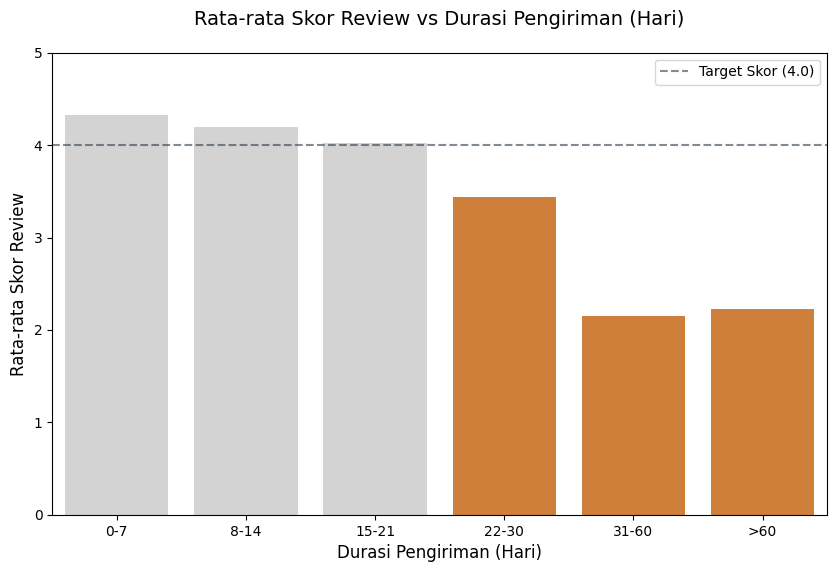

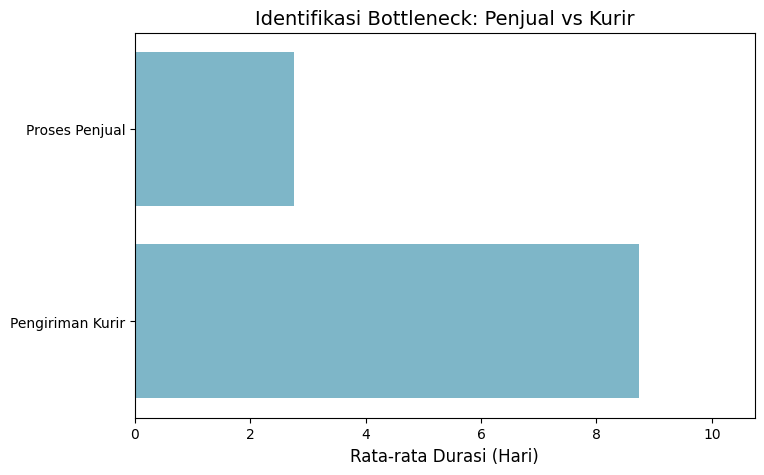

In [25]:
# Menghitung metrik waktu
# Waktu Proses Penjual
all_df['seller_process_time'] = (all_df['order_delivered_carrier_date'] - all_df['order_purchase_timestamp']).dt.days
# Waktu Pengiriman Kurir
all_df['courier_delivery_time'] = (all_df['order_delivered_customer_date'] - all_df['order_delivered_carrier_date']).dt.days
# Total Waktu Pengiriman
all_df['total_delivery_time'] = (all_df['order_delivered_customer_date'] - all_df['order_purchase_timestamp']).dt.days

# 2. Visualisasi Dampak Total Waktu terhadap Skor Review
all_df['delivery_binned'] = pd.cut(all_df['total_delivery_time'], bins=[0, 7, 14, 21, 30, 60, 250],
                                   labels=['0-7', '8-14', '15-21', '22-30', '31-60', '>60'])
review_by_delivery = all_df.groupby('delivery_binned', observed=True)['review_score'].mean().reset_index()

plt.figure(figsize=(10, 6))
colors = ["#D3D3D3" if x >= 4 else "#E67E22" for x in review_by_delivery['review_score']]

sns.barplot(
    data=review_by_delivery,
    x='delivery_binned',
    y='review_score',
    hue='delivery_binned',
    palette=colors,
    legend=False
)

plt.axhline(y=4, color='#2C3E50', linestyle='--', alpha=0.6, label='Target Skor (4.0)')
plt.title("Rata-rata Skor Review vs Durasi Pengiriman (Hari)", fontsize=14, pad=20)
plt.xlabel("Durasi Pengiriman (Hari)", fontsize=12)
plt.ylabel("Rata-rata Skor Review", fontsize=12)
plt.ylim(0, 5)
plt.legend()
plt.show()

# Analisis Bottleneck: Perbandingan Rata-rata Waktu Proses vs Pengiriman
avg_times = pd.DataFrame({
    'Tahapan': ['Proses Penjual', 'Pengiriman Kurir'],
    'Rata-rata Hari': [all_df['seller_process_time'].mean(), all_df['courier_delivery_time'].mean()]
})

plt.figure(figsize=(8, 5))
sns.barplot(data=avg_times, x='Rata-rata Hari', y='Tahapan', color="#72BCD4")
plt.title("Identifikasi Bottleneck: Penjual vs Kurir", fontsize=14)
plt.xlabel("Rata-rata Durasi (Hari)", fontsize=12)
plt.ylabel("", fontsize=12)
plt.xlim(0, max(avg_times['Rata-rata Hari']) + 2)
plt.show()

**Insight:**
- Terdapat korelasi negatif yang signifikan antara durasi pengiriman dan kepuasan pelanggan. Pelanggan cenderung memberikan skor rata-rata di atas 4.0 (Target Kepuasan) selama pesanan sampai dalam waktu maksimal 21 hari. Kekecewaan drastis mulai terlihat ketika pengiriman melampaui 30 hari, di mana skor ulasan jatuh ke kisaran 2.0.
- Berdasarkan visualisasi identifikasi bottleneck, durasi rata-rata yang dihabiskan di tangan kurir jauh lebih tinggi (sekitar 8-9 hari) dibandingkan dengan durasi proses internal penjual (sekitar 3 hari). Hal ini menunjukkan bahwa keterlambatan pengiriman lebih banyak disebabkan oleh pihak logistik eksternal daripada ketidaksiapan penjual.

### Pertanyaan 2: Kategori produk apa yang memberikan kontribusi pendapatan (Monetary) terbesar di 5 negara bagian (State) dengan jumlah transaksi tertinggi di Brasil?

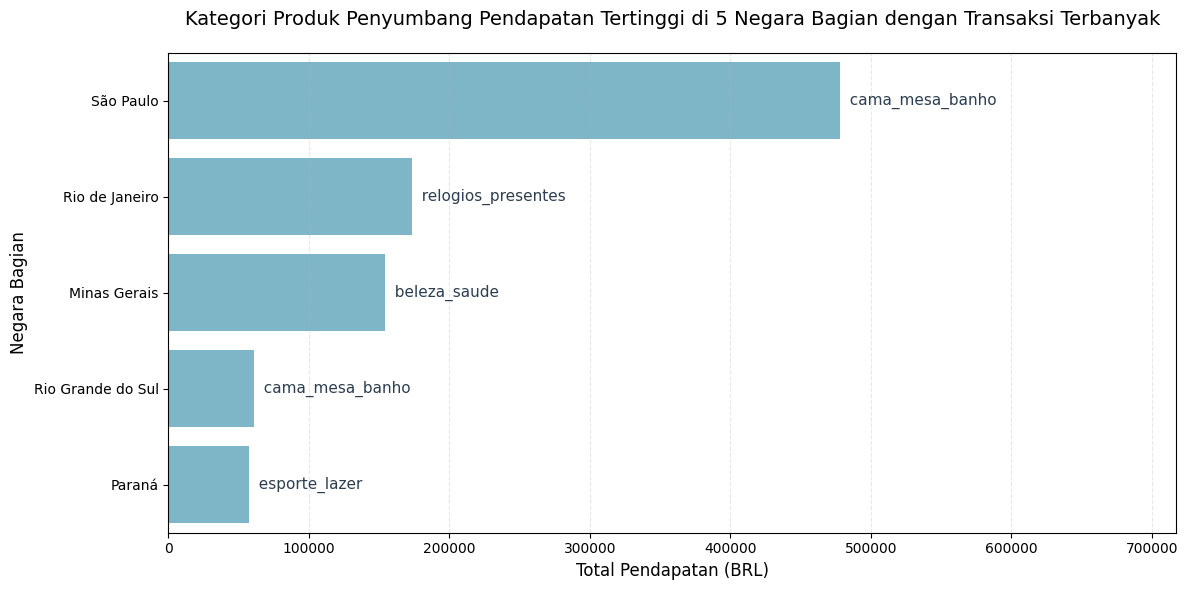

In [26]:
# Dictionary untuk mapping inisial ke nama lengkap Negara Bagian di Brasil
state_name_map = {
    'SP': 'São Paulo',
    'RJ': 'Rio de Janeiro',
    'MG': 'Minas Gerais',
    'RS': 'Rio Grande do Sul',
    'PR': 'Paraná'
}

# Mencari 5 Negara Bagian (State) dengan transaksi terbanyak
top_5_states_initials = all_df['customer_state'].value_counts().head(5).index

# Mencari kategori produk dengan total harga (Monetary) tertinggi di tiap negara bagian tersebut
state_product_monetary = all_df[all_df['customer_state'].isin(top_5_states_initials)].groupby(
    ['customer_state', 'product_category_name']
)['price'].sum().reset_index()

# Ambil top 1 kategori per state
top_cat_per_state = state_product_monetary.sort_values(['customer_state', 'price'], ascending=[True, False]).groupby('customer_state').head(1)

top_cat_per_state['customer_state_full'] = top_cat_per_state['customer_state'].map(state_name_map)
top_cat_per_state = top_cat_per_state.sort_values(by='price', ascending=False)
plt.figure(figsize=(12, 6))

sns.barplot(
    data=top_cat_per_state,
    x='price',
    y='customer_state_full',
    color="#72BCD4"
)

for index, value in enumerate(top_cat_per_state.itertuples()):
    plt.text(value.price, index, f"  {value.product_category_name}", va='center', fontsize=11, color='#2C3E50')

plt.title("Kategori Produk Penyumbang Pendapatan Tertinggi di 5 Negara Bagian dengan Transaksi Terbanyak", fontsize=14, pad=20)
plt.xlabel("Total Pendapatan (BRL)", fontsize=12)
plt.ylabel("Negara Bagian", fontsize=12)

plt.xlim(0, top_cat_per_state['price'].max() * 1.5)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

**Insight:**
- Negara bagian São Paulo merupakan kontributor pendapatan terbesar dengan total transaksi mendekati 500.000 BRL. Kategori produk cama_mesa_banho (perlengkapan rumah) menjadi primadona yang mendominasi wilayah ini, serta kembali muncul sebagai kategori unggulan di Rio Grande do Sul.
- Terdapat pola unik di negara bagian lain, Rio de Janeiro menyumbang pendapatan besar melalui kategori relogios_presentes (jam tangan & hadiah), sementara Minas Gerais didominasi oleh kategori beleza_saude (kecantikan & kesehatan). Hal ini mengindikasikan perlunya strategi pemasaran yang disesuaikan dengan preferensi kategori di tiap wilayah strategis tersebut.

## Analisis Lanjutan (Opsional)

### Pertanyaan 3: Bagaimana klasifikasi pelanggan berdasarkan skor RFM (Recency, Frequency, Monetary), dan segmen mana yang memiliki nilai ekonomi paling strategis bagi perusahaan?

### RFM Analysis

Analisis RFM (Recency, Frequency, Monetary) merupakan teknik segmentasi pelanggan yang digunakan untuk mengevaluasi nilai ekonomi serta perilaku pelanggan berdasarkan histori transaksi mereka. Penjelasan dari ketiga komponen utama:
- Recency: Menghitung jumlah hari sejak transaksi terakhir yang dilakukan pelanggan. Tujuannya adalah untuk mengukur tingkat keaktifan pelanggan, di mana pelanggan yang baru saja bertransaksi memiliki peluang lebih tinggi untuk kembali melakukan pembelian.
- Frequency: Menghitung total jumlah transaksi unik yang dilakukan oleh pelanggan dalam periode waktu tertentu. Hal ini digunakan untuk mengidentifikasi tingkat loyalitas pelanggan terhadap platform.
- Monetary: Menghitung total pengeluaran atau nilai transaksi yang telah dikontribusikan oleh pelanggan. Variabel ini sangat krusial untuk mengidentifikasi segmen pelanggan yang memberikan keuntungan finansial terbesar bagi perusahaan.

Implementasi teknik ini dilakukan dengan mengklasifikasikan pelanggan ke dalam beberapa segmen strategis menggunakan metode Manual Grouping atau Binning. Melalui segmentasi ini, perusahaan dapat mengidentifikasi kelompok pelanggan seperti Champions yang sangat loyal dan aktif, hingga segmen At Risk yang memerlukan upaya reaktivasi karena sudah lama tidak bertransaksi meskipun memiliki nilai moneter yang besar. Strategi pemasaran yang disesuaikan berdasarkan segmen RFM ini diharapkan dapat meningkatkan retensi pelanggan serta mengoptimalkan pendapatan secara efektif tanpa harus bergantung pada algoritma machine learning.

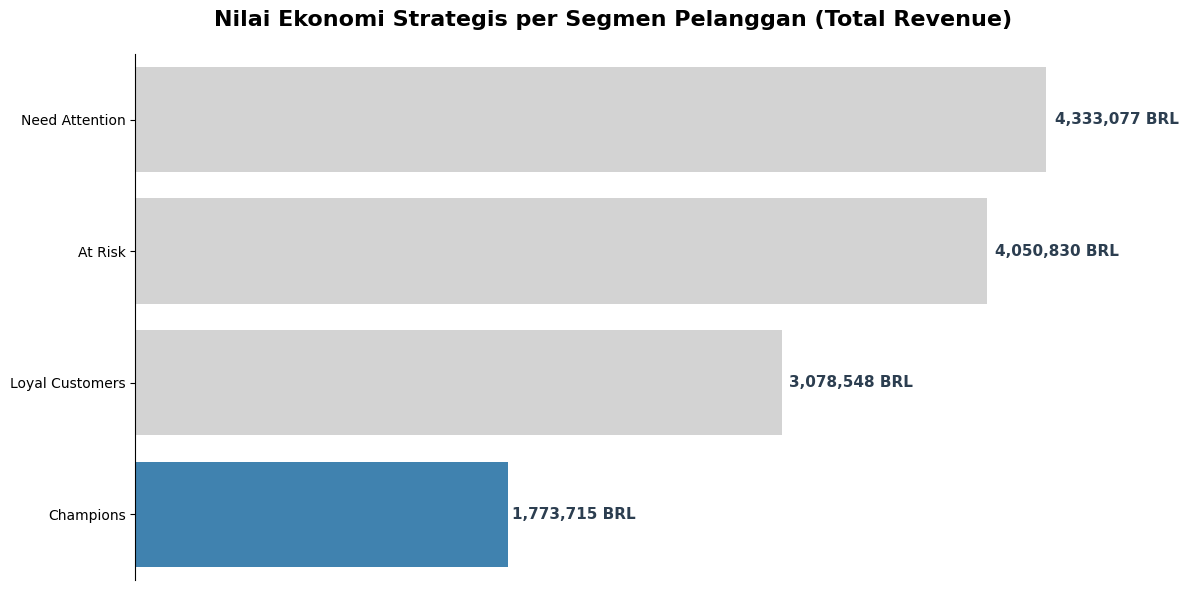

In [27]:
# Kalkulasi RFM
rfm_df = all_df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (all_df['order_purchase_timestamp'].max() - x.max()).days,
    'order_id': 'nunique',
    'price': 'sum'
}).reset_index()
rfm_df.columns = ['customer_id', 'recency', 'frequency', 'monetary']

# coring (1-5) menggunakan quintiles
rfm_df['r_rank'] = rfm_df['recency'].rank(ascending=False)
rfm_df['f_rank'] = rfm_df['frequency'].rank(ascending=True)
rfm_df['m_rank'] = rfm_df['monetary'].rank(ascending=True)

# Normalisasi skor ke skala 1-5
rfm_df['r_score'] = pd.qcut(rfm_df['r_rank'], 5, labels=[1, 2, 3, 4, 5])
rfm_df['f_score'] = pd.qcut(rfm_df['f_rank'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
rfm_df['m_score'] = pd.qcut(rfm_df['m_rank'], 5, labels=[1, 2, 3, 4, 5])

# Klasifikasi Segmen Manual Grouping
def segment_customer(df):
    if df['r_score'] >= 4 and df['f_score'] >= 4 and df['m_score'] >= 4:
        return 'Champions'
    elif df['r_score'] >= 3 and df['f_score'] >= 3:
        return 'Loyal Customers'
    elif df['r_score'] <= 2 and df['m_score'] >= 4:
        return 'At Risk'
    else:
        return 'Need Attention'

rfm_df['customer_segment'] = rfm_df.apply(segment_customer, axis=1)

# Visualisasi Kontribusi Monetary per Segmen
segment_monetary = rfm_df.groupby('customer_segment')['monetary'].sum().reset_index()
segment_monetary = segment_monetary.sort_values(by='monetary', ascending=False)

plt.figure(figsize=(12, 6))

colors = ["#2E86C1" if x == 'Champions' else "#D3D3D3" for x in segment_monetary['customer_segment']]

ax = sns.barplot(
    data=segment_monetary,
    x='monetary',
    y='customer_segment',
    hue='customer_segment',
    palette=colors,
    legend=False
)

for p in ax.patches:
    width = p.get_width()
    ax.text(width + (width * 0.01),
            p.get_y() + p.get_height() / 2,
            '{:,.0f} BRL'.format(width),
            va='center', fontsize=11, color='#2C3E50', weight='bold')

plt.title("Nilai Ekonomi Strategis per Segmen Pelanggan (Total Revenue)", fontsize=16, pad=20, weight='bold')
plt.xlabel("Total Kontribusi Pendapatan (BRL)", fontsize=12, labelpad=10)
plt.ylabel(None)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)
ax.get_xaxis().set_visible(False)

plt.tight_layout()
plt.show()

**Insight:**
- Segmen pelanggan yang masuk kategori Need Attention secara kolektif menyumbang nilai ekonomi tertinggi, yaitu sebesar 4.333.077 BRL. Angka ini sangat besar, menandakan bahwa perusahaan memiliki basis massa pelanggan yang luas namun berisiko hilang jika tidak segera diberikan strategi retensi atau promo re-aktivasi.
- Pelanggan kategori At Risk menyumbang nilai moneter yang sangat tinggi (4.050.830 BRL), menunjukkan mereka adalah pelanggan lama yang pernah belanja besar namun sudah lama tidak bertransaksi. Sementara itu, segmen Champions meskipun menyumbang nilai moneter terkecil di grafik ini (1.773.715 BRL), mereka adalah kelompok yang paling loyal dan harus dipertahankan sebagai duta merek karena skor RFM mereka yang paling sempurna.

## Conclusion

- Berdasarkan hasil analisis, terdapat korelasi negatif yang signifikan antara durasi pengiriman dan kepuasan pelanggan, di mana skor ulasan rata-rata tetap terjaga di atas 4.0 (target kepuasan) selama pesanan sampai dalam kurun waktu maksimal 21 hari, namun menurun drastis hingga menyentuh angka 2.0 saat pengiriman melampaui 30 hari. Identifikasi bottleneck menunjukkan bahwa tahap pengiriman kurir (logistik eksternal) memiliki durasi rata-rata yang jauh lebih lama, yaitu sekitar 8-9 hari, dibandingkan proses internal penjual yang hanya memakan waktu sekitar 3 hari, sehingga efisiensi kurir menjadi faktor utama yang paling memengaruhi keterlambatan dan penurunan skor ulasan.
- Terkait distribusi pendapatan di lima negara bagian dengan transaksi tertinggi, wilayah São Paulo mencatatkan pendapatan terbesar yang didominasi oleh kategori cama_mesa_banho (perlengkapan rumah), diikuti oleh Rio de Janeiro yang memberikan kontribusi signifikan melalui kategori relogios_presentes (jam tangan & hadiah), kemudian Minas Gerais yang unggul pada kategori beleza_saude (kecantikan & kesehatan), sementara Rio Grande do Sul kembali didominasi oleh kategori cama_mesa_banho, dan terakhir wilayah Paraná yang didominasi oleh kategori esporte_lazer (olahraga & hiburan).
- Klasifikasi pelanggan menggunakan skor RFM menunjukkan bahwa segmen Need Attention memiliki nilai ekonomi paling strategis karena menyumbang total pendapatan terbesar mencapai 4.333.077 BRL, diikuti oleh segmen At Risk dengan kontribusi sebesar 4.050.830 BRL, sementara segmen Loyal Customers dan Champions masing-masing menyumbang 3.078.548 BRL dan 1.773.715 BRL. Meskipun segmen Champions memiliki nilai moneter terkecil dalam perbandingan ini, mereka tetap menjadi aset strategis sebagai pelanggan paling loyal, namun fokus retensi utama harus diarahkan pada segmen Need Attention dan At Risk untuk mencegah hilangnya potensi pendapatan yang sangat besar bagi perusahaan.